In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Capstone')

Mounted at /content/drive


# EDA For Groceries Dataset
Souce URL: https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset



In [ ]:
grocery_data = pd.read_csv('data/Groceries_dataset.csv')
grocery_data.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [ ]:
grocery_data.dtypes

,0
Member_number,int64
Date,object
itemDescription,object


## Distribution of Columns

### Date — transactions over time

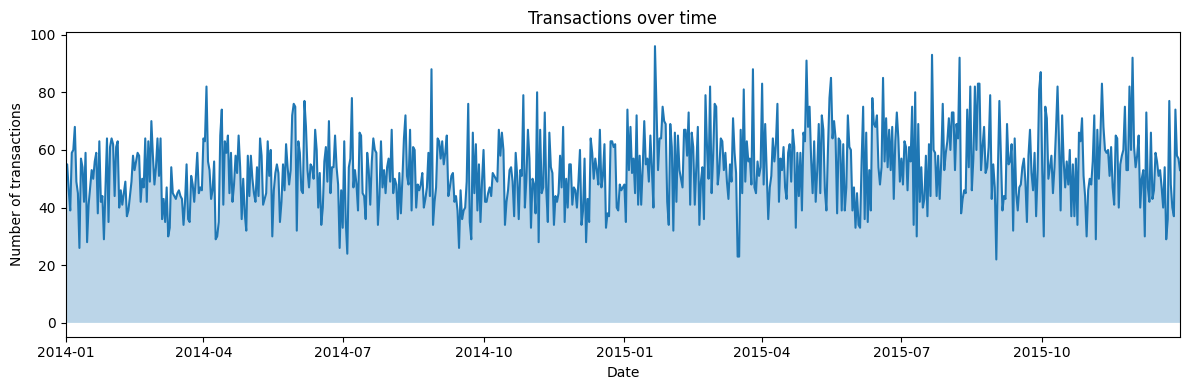

In [ ]:
grocery_data['Date'] = pd.to_datetime(grocery_data['Date'], format='%d-%m-%Y')

daily_counts = grocery_data.groupby('Date').size().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(daily_counts.index, daily_counts.values, alpha=0.3)
ax.plot(daily_counts.index, daily_counts.values, linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Number of transactions')
ax.set_title('Transactions over time')
ax.margins(x=0)
plt.tight_layout()
plt.show()

### itemDescription — top 20 items

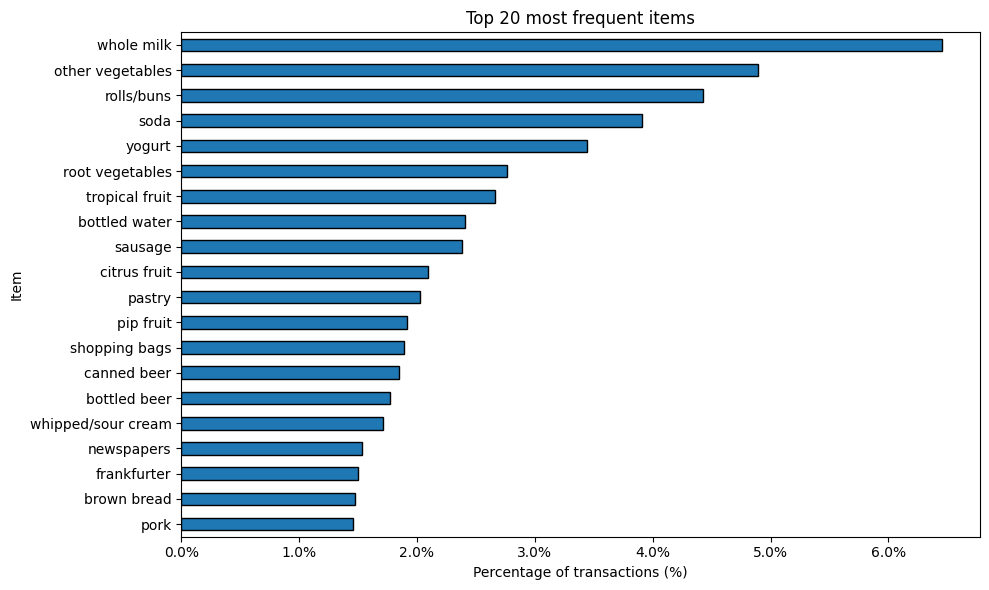

In [ ]:
top_items = grocery_data['itemDescription'].value_counts(normalize=True).head(20) * 100

fig, ax = plt.subplots(figsize=(10, 6))
top_items[::-1].plot(kind='barh', ax=ax, edgecolor='black')
ax.set_xlabel('Percentage of transactions (%)')
ax.set_ylabel('Item')
ax.set_title('Top 20 most frequent items')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.show()